# C03 回测闭环与 RQAlpha 模板
前两节课我们已经解决了两个问题：
- 有什么数据可以用
- 数据里能提什么特征

这一节开始回答第三个问题：

> 如果我真的按照某个规则交易，账户净值会怎么变化？

所以本节重点不是“最好的策略”，而是“最小可用回测闭环”。


In [ ]:
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
UNIVERSE = ["000001.XSHE", "000002.XSHE", "600000.XSHG", "601318.XSHG", "600519.XSHG"]

import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

import rqdatac

candidate_fonts = [
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK SC",
    "Source Han Sans SC",
    "PingFang SC",
    "WenQuanYi Micro Hei",
    "Arial Unicode MS",
]
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in candidate_fonts:
    if font_name in installed_fonts:
        plt.rcParams["font.sans-serif"] = [font_name]
        break
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore", message=r"Glyph .* missing from font")
warnings.filterwarnings("ignore", category=UserWarning, module=r"IPython\.core\.pylabtools")

PASSWD = ""

if PASSWD:
    rqdatac.init('license', PASSWD)
    print("rqdatac initialized")
else:
    print("Please fill PASSWD first")


rqdatac initialized


d:\python_workspace\Quant\.venv\liangwen2\Lib\site-packages\rqdatac\client.py:224: UserWarning: rqdatac is already inited. Settings will be changed.
  warnings.warn("rqdatac is already inited. Settings will be changed.", stacklevel=0)


## 1) 回测闭环到底是什么
一个最简单的回测框架，至少要包含四件事：
1. 什么时候调仓
2. 每次买什么、买多少
3. 持有期间收益怎么计算
4. 如何把每一期收益累积成净值曲线


### 1.1 为什么这节课不急着上复杂策略
因为对零基础同学来说，回测最容易学偏：
- 看了很多净值图
- 但不知道净值是怎么一步步算出来的

这节课的目标，是把“信号 -> 权重 -> 收益 -> 净值”这条链路讲清楚。


In [49]:
# 这里选几只宽基ETF做演示，更适合讲“组合”和“调仓”
assets = ["510300.XSHG", "510500.XSHG", "159915.XSHE", "513100.XSHG"]
close = rqdatac.get_price(
    assets,
    start_date=START_DATE,
    end_date=END_DATE,
    fields=["close"],
    adjust_type="pre",
    expect_df=True,
).reset_index()

close = close.sort_values(["order_book_id", "date"]).copy()
close["ret"] = close["close"] / close.groupby("order_book_id")["close"].shift(1) - 1
close.head()


,order_book_id,date,close,ret
1452,159915.XSHE,2022-01-04,3.154,NaN
1453,159915.XSHE,2022-01-05,3.064,-0.028535
1454,159915.XSHE,2022-01-06,3.034,-0.009791
1455,159915.XSHE,2022-01-07,3.003,-0.010218
1456,159915.XSHE,2022-01-10,2.998,-0.001665


In [50]:
# 转成宽表之后，月度调仓和横截面排名都会更直观
close_wide = close.pivot(index="date", columns="order_book_id", values="close")
ret_wide = close.pivot(index="date", columns="order_book_id", values="ret")
close_wide.head()


order_book_id,159915.XSHE,510300.XSHG,510500.XSHG,513100.XSHG
date,,,,
2022-01-04,3.154,4.514329,6.934875,1.0812
2022-01-05,3.064,4.471809,6.798946,1.0594
2022-01-06,3.034,4.421148,6.807337,1.0302
2022-01-07,3.003,4.432004,6.772935,1.0376
2022-01-10,2.998,4.443765,6.773774,1.0284


## 2) 先定义一个足够简单的策略信号
课堂上保留一个最小版本：
- 每个月月底看一次
- 计算过去 20 个交易日动量
- 选动量最高的 2 个 ETF
- 等权持有到下一个调仓日

这条规则足够简单，但能把整个回测流程走通。


In [51]:
# 20日动量：今天价格 / 20天前价格 - 1
momentum_20 = close_wide / close_wide.shift(20) - 1

# 这里取“每个月最后一个交易日”，而不是自然月月末
rebalance_dates = pd.DatetimeIndex(
    momentum_20.groupby(momentum_20.index.to_period("M")).tail(1).index
)

momentum_20.loc[rebalance_dates].head()


order_book_id,159915.XSHE,510300.XSHG,510500.XSHG,513100.XSHG
date,,,,
2022-01-28,NaN,NaN,NaN,NaN
2022-02-28,-0.059419,-0.044923,-0.018870,-0.057834
2022-03-31,-0.048077,-0.071947,-0.077572,0.068478
2022-04-29,-0.140230,-0.055072,-0.115154,-0.085859
2022-05-31,0.081557,0.044444,0.116451,-0.027996


In [52]:
# 每个调仓日选动量最高的 2 个标的，并做等权配置
weights = pd.DataFrame(0.0, index=rebalance_dates, columns=momentum_20.columns)

for dt in rebalance_dates:
    score = momentum_20.loc[dt].dropna().sort_values(ascending=False)
    top2 = score.head(2).index.tolist()
    if top2:
        weights.loc[dt, top2] = 1 / len(top2)

weights.head()


order_book_id,159915.XSHE,510300.XSHG,510500.XSHG,513100.XSHG
date,,,,
2022-01-28,0.0,0.0,0.0,0.0
2022-02-28,0.0,0.5,0.5,0.0
2022-03-31,0.5,0.0,0.0,0.5
2022-04-29,0.0,0.5,0.0,0.5
2022-05-31,0.5,0.0,0.5,0.0


### 2.1 权重表为什么是回测里的关键中间层
很多同学会从“信号”直接跳到“净值”，但中间其实少了一层：
- 信号告诉你买谁
- 权重告诉你买多少

真正的回测执行，更像是“按权重更新组合”，而不是“凭印象下单”。


In [53]:
# 把月度权重扩展成日频权重：调仓日更新，其余日期沿用上一次持仓
daily_weights = weights.reindex(ret_wide.index).ffill().fillna(0)

# 组合当日收益 = 前一日持仓权重 * 当日资产收益
portfolio_ret = (daily_weights.shift(1) * ret_wide).sum(axis=1).fillna(0)
nav = (1 + portfolio_ret).cumprod()
nav[30:50]


date
2022-02-22    1.000000
2022-02-23    1.000000
2022-02-24    1.000000
2022-02-25    1.000000
2022-02-28    1.000000
2022-03-01    1.005456
2022-03-02    1.001834
2022-03-03    0.998074
2022-03-04    0.989043
2022-03-07    0.961454
2022-03-08    0.934583
2022-03-09    0.922092
2022-03-10    0.936000
2022-03-11    0.945696
2022-03-14    0.917962
2022-03-15    0.868994
2022-03-16    0.903190
2022-03-17    0.919715
2022-03-18    0.927468
2022-03-21    0.928577
dtype: float64

### 2.2 回测链路里最关键的几张表
如果只保留最核心的对象，一套最小回测通常会出现四张表：

1. 收盘价表
2. 收益率表
3. 调仓日权重表
4. 日频持仓表

前面已经把信号和权重算出来了，这里再把几个关键对象的形状看清楚，后面映射到 `RQAlpha` 会容易很多。


In [54]:
# 先看回测链路里最关键的几个对象长什么样
pipeline_shapes = pd.DataFrame({
    "object": ["close", "close_wide", "ret_wide", "momentum_20", "weights"],
    "rows": [len(close), len(close_wide), len(ret_wide), len(momentum_20), len(weights)],
    "cols": [close.shape[1], close_wide.shape[1], ret_wide.shape[1], momentum_20.shape[1], weights.shape[1]],
})

pipeline_shapes


,object,rows,cols
0,close,2904,4
1,close_wide,726,4
2,ret_wide,726,4
3,momentum_20,726,4
4,weights,36,4


## 3) 加一点现实交易摩擦
真实交易不会只有“理想收益”，还会有：
- 手续费
- 滑点
- 调仓时的换手成本

本节先加最简单的一层：按持仓变化量估算交易费用。


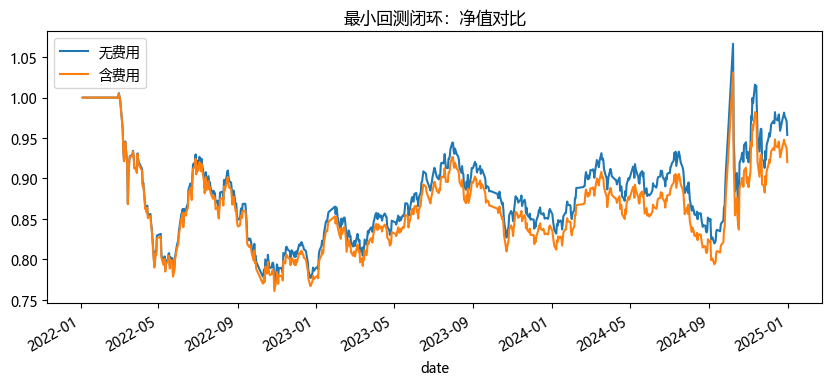

In [55]:
# 用持仓变化量近似换手，再乘上费率
turnover = daily_weights.diff().abs().sum(axis=1).fillna(0)
fee_rate = 0.001
portfolio_ret_after_fee = portfolio_ret - turnover * fee_rate
nav_after_fee = (1 + portfolio_ret_after_fee).cumprod()

fig, ax = plt.subplots(figsize=(10, 4))
nav.plot(ax=ax, label="无费用")
nav_after_fee.plot(ax=ax, label="含费用")
ax.set_title("最小回测闭环：净值对比")
ax.legend()
plt.show()


In [56]:
# 再补两个常看的指标：最大回撤和胜率
running_max = nav_after_fee.cummax()
drawdown = nav_after_fee / running_max - 1  # 当前净值相对于历史最高点跌了多少，小于0。
max_drawdown = drawdown.min()
win_rate = (portfolio_ret_after_fee > 0).mean()  # 收益为正的日子占比有多少。
rf = 0.02

perf_table = pd.Series({
    "cum_return": nav_after_fee.iloc[-1] - 1,
    "annual_return": nav_after_fee.iloc[-1] ** (252 / len(nav_after_fee)) - 1,  # assume 252个交易日
    "annual_vol": portfolio_ret_after_fee.std() * (252 ** 0.5),  # 方差按时间近似线性累加，标准差 = 方差开根号。
    "sharpe": (nav_after_fee.iloc[-1] ** (252 / len(nav_after_fee)) - 1 - rf) / (portfolio_ret_after_fee.std() * (252 ** 0.5)),
    "max_drawdown": max_drawdown,
    "win_rate": win_rate,
}).round(4)

perf_table


cum_return      -0.0798
annual_return   -0.0284
annual_vol       0.1995
sharpe          -0.2429
max_drawdown    -0.2427
win_rate         0.4573
dtype: float64

### 3.1 不只看收益，还要看回撤
净值曲线看起来在涨，并不代表过程舒服。

> 回撤回答的是：策略从一个历史高点跌下来时，最多会跌多深。

所以这一节不能只看期末收益，还要开始建立“收益和风险一起看”的意识。


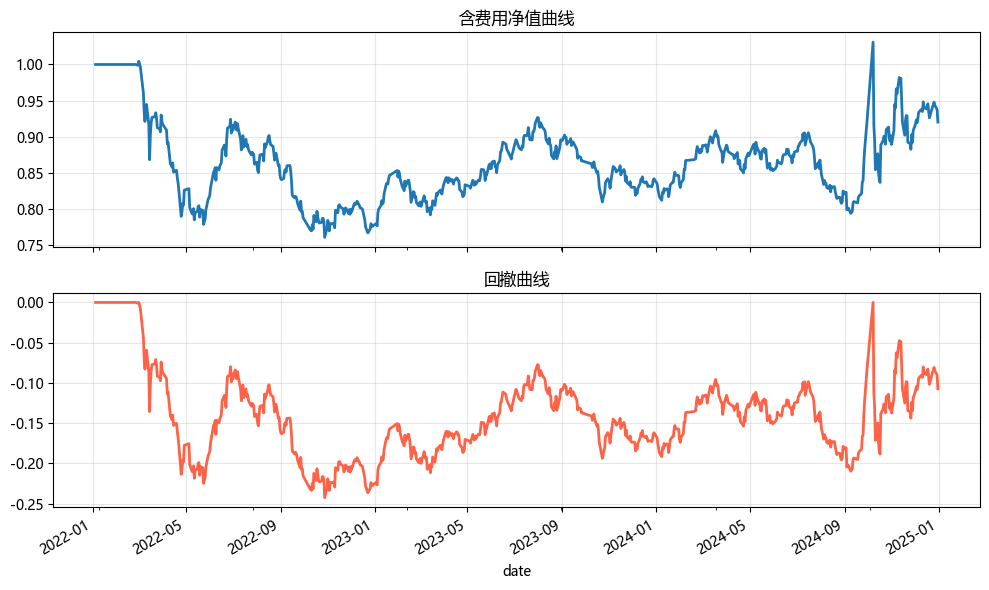

In [57]:
# 把净值和回撤放在一起看，会比只看一张净值图更完整
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
nav_after_fee.plot(ax=axes[0], lw=2, title="含费用净值曲线")
drawdown.plot(ax=axes[1], lw=2, color="tomato", title="回撤曲线")
axes[0].grid(alpha=0.3)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 3.2 “手写回测”最值得补的一点
一个很重要的思想：回测不要一上来就写成一整块。

- 调仓日怎么定
- 权重怎么生成
- 收益怎么累计

最好拆成：
- 小函数
- 中间表
- 明确输入输出


In [58]:
# 把上面的逻辑再拆成函数，和旧讲义的写法保持一致

def get_rebalance_dates(index):  # index 通常是一张日频表的日期索引
    # 取每个月最后一个真实交易日，而不是自然月月末
    idx = pd.DatetimeIndex(index)
    return pd.DatetimeIndex(pd.Series(idx, index=idx).groupby(idx.to_period("M")).tail(1).values)

def build_topn_weights(score_df, n=2):
    rebal_dates = get_rebalance_dates(score_df.index)
    w = pd.DataFrame(0.0, index=rebal_dates, columns=score_df.columns)
    for dt in rebal_dates:
        score = score_df.loc[dt].dropna().sort_values(ascending=False)
        topn = score.head(n).index.tolist()
        if topn:
            w.loc[dt, topn] = 1 / len(topn)  # 等权
    return w

weights_func = build_topn_weights(momentum_20, n=2)
weights_func.head()


order_book_id,159915.XSHE,510300.XSHG,510500.XSHG,513100.XSHG
2022-01-28,0.0,0.0,0.0,0.0
2022-02-28,0.0,0.5,0.5,0.0
2022-03-31,0.5,0.0,0.0,0.5
2022-04-29,0.0,0.5,0.0,0.5
2022-05-31,0.5,0.0,0.5,0.0


### 3.3 再补一个过渡对象：`allocation_dict`
如果后面要接 `RQAlpha`，一个很常见的做法是先把权重表转换成字典：

- key 是日期
- value 是当期目标权重

这样从研究环境过渡到下单环境会更自然。


In [59]:
# 把权重表转成更接近 RQAlpha 下单接口的字典结构
allocation_dict = {}
for dt, row in weights_func.iterrows():
    allocation_dict[dt.date()] = row[row > 0].to_dict()

list(allocation_dict.items())[:3]


[(datetime.date(2022, 1, 28), {}),
 (datetime.date(2022, 2, 28), {'510300.XSHG': 0.5, '510500.XSHG': 0.5}),
 (datetime.date(2022, 3, 31), {'159915.XSHE': 0.5, '513100.XSHG': 0.5})]

### 3.4 再补一个基准比较
如果只看策略自己的净值，很容易高估它的表现。
和一个简单基准放在一起，才更容易判断：

- 是策略真的有优势
- 还是市场整体都在涨


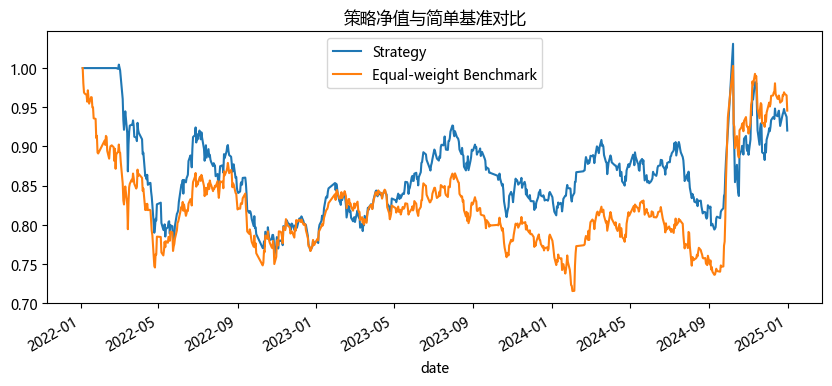

In [60]:
benchmark_ret = ret_wide.mean(axis=1).fillna(0)
benchmark_nav = (1 + benchmark_ret).cumprod()

fig, ax = plt.subplots(figsize=(10, 4))
nav_after_fee.plot(ax=ax, label="Strategy")
benchmark_nav.plot(ax=ax, label="Equal-weight Benchmark")
ax.set_title("策略净值与简单基准对比")
ax.legend()
plt.show()


### 3.5 这几张结果到底在告诉我们什么
看到这里，最值得学生带走的有三件事：

1. 回测不是只产出一张净值图
2. 手续费会显著改变结果
3. 回撤能帮助我们理解“赚钱过程是否稳定”

也就是说，回测输出本身就是研究对象，不只是最后一个收益数字。


## 4) RQAlpha 模板为什么还值得讲
手写回测能帮我们理解逻辑，但研究和实盘之间还差一层标准化框架。

- `init`
- `scheduler`
- `handle_bar`
- `config`

这一部分的目标不是今天把每个参数讲完，而是让学生知道框架长什么样。

> 也就是先会“看模板”，再慢慢会“改模板”。


In [61]:
# 下面这段是模板，不要求这节课现场一定跑通。
# 它的作用是帮助大家把“研究环境里的逻辑”映射到 RQAlpha 结构里。

# from rqalpha import run_func

# def init(context):
#     context.assets = ["510300.XSHG", "510500.XSHG", "159915.XSHE", "513100.XSHG"]
#
# def handle_bar(context, bar_dict):
#     # 这里会放入计算信号、更新权重、下单的逻辑
#     pass
#
# config = {...}
# result = run_func(init=init, handle_bar=handle_bar, config=config)


### 4.1 `config` 里最值得学生记住什么
很多同学第一次看 `config` 会觉得很长，但真正需要先记住的只有几类：

1. `accounts`：有多少钱
2. `start_date / end_date`：回测区间
3. `benchmark`：拿谁做比较
4. `sys_simulation / sys_transaction_cost`：交易细节和成本

先把这四类参数看懂，后面再细抠其他开关就容易很多。


In [62]:
config_example = {
    "base": {
        "accounts": {"STOCK": 1000000},
        "start_date": START_DATE,
        "end_date": END_DATE,
    },
    "mod": {
        "sys_analyser": {"plot": True, "benchmark": "000300.XSHG"},
        "sys_simulation": {
            "slippage": 0,
            "matching_type": "vwap",
            "volume_limit": True,
            "volume_percent": 0.02,
        },
        "sys_transaction_cost": {
            "commission_multiplier": 3/8,
            "tax_multiplier": 1,
            "cn_stock_min_commission": 5,
        },
    },
    "extra": {"log_level": "error"},
}

config_example


{'base': {'accounts': {'STOCK': 1000000},
  'start_date': '2022-01-01',
  'end_date': '2024-12-31'},
 'mod': {'sys_analyser': {'plot': True, 'benchmark': '000300.XSHG'},
  'sys_simulation': {'slippage': 0,
   'matching_type': 'vwap',
   'volume_limit': True,
   'volume_percent': 0.02},
  'sys_transaction_cost': {'commission_multiplier': 0.375,
   'tax_multiplier': 1,
   'cn_stock_min_commission': 5}},
 'extra': {'log_level': 'error'}}

### 4.2 RQAlpha 结果结构也值得讲一下
真正跑完 `RQAlpha` 后，结果通常不只是一张图。

- 回测摘要
- 账户净值
- 基准表现
- 持仓细节

所以学生至少要知道结果对象里常见的几层结构是什么。


In [63]:
# 如果以后真的跑 RQAlpha，最常见的查看方式会长这样：
# result['sys_analyser'].keys()
# result['sys_analyser']['summary']
# result['sys_analyser']['stock_account'].head()
#
# 这几个对象分别对应：
# - 回测摘要
# - 账户权益变化
# - 基准表现
# - 持仓细节


### 4.3 旧讲义里的 `scheduler` / `order_target_portfolio` 写法
旧讲义里很值得保留的一点是：先把“调仓日触发”和“目标权重下单”这两个动作分开。

- 用 `scheduler` 管什么时候调仓
- 用 `handle_bar` 管具体执行什么

这样从权重表过渡到框架内下单会更顺。


In [64]:
# 这段模板展示“日期触发 + 目标权重下单”的基本结构
# from rqalpha_plus import run_func
# import sys
#
# def init(context):
#     context.allocation = allocation_dict
#     context.new_allocation = None
#     rqdatac.scheduler.run_monthly(print_time, monthday=1)
#
# def print_time(context, bar_dict):
#     sys.stdout.write(str(context.now.strftime("%Y-%m") + "  "))
#
# def handle_bar(context, bar_dict):
#     next_date = context.now.date()
#     if next_date in context.allocation:
#         context.new_allocation = context.allocation[next_date]
#     if context.new_allocation is not None:
#         rqdatac.order_target_portfolio(context.new_allocation)


## 5) 课上小练习


### 练习 1：自己改成 top1 策略
要求：
1. 把上面的 `top2` 改成 `top1`
2. 重新得到 `weights` 和 `nav`
3. 对比 top1 和 top2 的净值曲线


In [ ]:
# 练习 1：学生现场自己写
# 提示：只需要修改选取标的的数量，其余逻辑基本不变


In [66]:
# 参考答案
weights_top1 = pd.DataFrame(0.0, index=rebalance_dates, columns=momentum_20.columns)
for dt in rebalance_dates:
    score = momentum_20.loc[dt].dropna().sort_values(ascending=False)
    top1 = score.head(1).index.tolist()
    if top1:
        weights_top1.loc[dt, top1] = 1.0

daily_weights_top1 = weights_top1.reindex(ret_wide.index).ffill().fillna(0)
ret_top1 = (daily_weights_top1.shift(1) * ret_wide).sum(axis=1).fillna(0)
nav_top1 = (1 + ret_top1).cumprod()
nav_top1.tail()


date
2024-12-25    1.079803
2024-12-26    1.084337
2024-12-27    1.076564
2024-12-30    1.061666
2024-12-31    1.055188
dtype: float64

### 练习 2：自己加手续费
要求：
1. 基于 `daily_weights` 计算换手 `turnover`
2. 设定费率 `0.001`
3. 得到含手续费的净值序列


In [ ]:
# 练习 2：学生现场自己写


In [68]:
# 参考答案
turnover_ex2 = daily_weights.diff().abs().sum(axis=1).fillna(0)
fee_rate_ex2 = 0.001
ret_ex2 = portfolio_ret - turnover_ex2 * fee_rate_ex2
nav_ex2 = (1 + ret_ex2).cumprod()
nav_ex2.tail()


date
2024-12-25    0.943647
2024-12-26    0.947816
2024-12-27    0.943763
2024-12-30    0.937669
2024-12-31    0.920228
dtype: float64

## 小结
这一节的关键词是：**回测闭环**。

到这里为止，大家应该能回答四个问题：
1. 调仓日是怎么定的
2. 权重表是怎么生成的
3. 组合收益如何由单资产收益加总得到
4. 交易成本为什么会显著影响结果

本节常见易错点：
1. 只有信号，没有权重
2. 直接用当日权重乘当日收益，忽略了“先持仓、后发生收益”的时序
3. 完全忽略交易成本
